# Imports

In [1]:
from IPython.display import Image, display, SVG, HTML
from typing import Dict, List, Tuple, Generator, Optional, Any, Literal
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
import concurrent.futures
import gc

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Rectangle, FancyArrowPatch

import seaborn as sns
import pandas as pd
import numpy as np
import os
import re
import time
import datetime
import multiprocessing

from tqdm import tqdm
import otf2
import hatchet as ht
import thicket as tt
from collections import defaultdict

In [2]:
# Track how long the notebook takes to run
NOTEBOOK_START_TIME = time.time()
print(f"Notebook started at {NOTEBOOK_START_TIME} ({datetime.datetime.fromtimestamp(NOTEBOOK_START_TIME)})")

Notebook started at 1766085302.070041 (2025-12-18 14:15:02.070041)


In [3]:
MI250X_HPL_NODE_RANKS = {
	'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3', 'MPI Rank 4', 'MPI Rank 5', 'MPI Rank 6', 'MPI Rank 7'],
}
MI250X_HPG_NODE_RANKS = MI250X_HPL_NODE_RANKS

MI300A_HPL_NODE_RANKS = {
	'node0': ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3']
}
MI300A_HPG_NODE_RANKS = MI300A_HPL_NODE_RANKS

### Define The Metrics to Attribute to Each Rank

This defines which MPI rank is on which GCD (frontier) or APU (el capitan). Two ranks drawing from the same GPU (each GPU has 2 GCDs) will have their energy consumption estimated independently based on their exclusive runtime.

In [4]:
MI250X_HPL_RANKS_TO_METRICS = {
	'MPI Rank 0': ['A2rocm_smi:::energy_count:device=4'],
	'MPI Rank 1': ['A2rocm_smi:::energy_count:device=4'],
	'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 3': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 4': ['A2rocm_smi:::energy_count:device=6'],
	'MPI Rank 5': ['A2rocm_smi:::energy_count:device=6'],
	'MPI Rank 6': ['A2rocm_smi:::energy_count:device=0'],
	'MPI Rank 7': ['A2rocm_smi:::energy_count:device=0'],
}
MI300A_HPL_RANKS_TO_METRICS = {
	'MPI Rank 0': ['A2rocm_smi:::energy_count:device=0'],
	'MPI Rank 1': ['A2rocm_smi:::energy_count:device=1'],
	'MPI Rank 2': ['A2rocm_smi:::energy_count:device=2'],
	'MPI Rank 3': ['A2rocm_smi:::energy_count:device=3'],
}

MI250X_HPG_RANKS_TO_METRICS = MI250X_HPL_RANKS_TO_METRICS
MI300A_HPG_RANKS_TO_METRICS = MI300A_HPL_RANKS_TO_METRICS

### Define Which Metrics to Track in the Traces

This defines the metrics we're going to pay attention to when parsing the traces.
All metrics that are used above must be included here.

In [5]:

METRICS_TO_TRACK = [
    'A2rocm_smi:::energy_count:device=0',
    'A2rocm_smi:::energy_count:device=1',
    'A2rocm_smi:::energy_count:device=2',
    'A2rocm_smi:::energy_count:device=3',
    'A2rocm_smi:::energy_count:device=4',
    'A2rocm_smi:::energy_count:device=6',
    
    'A2coretemp:::craypm:accel0_energy',
    'A2coretemp:::craypm:accel1_energy',
    'A2coretemp:::craypm:accel2_energy',
    'A2coretemp:::craypm:accel3_energy',
    
    'A2coretemp:::craypm:accel0_power',
    'A2coretemp:::craypm:accel1_power',
    'A2coretemp:::craypm:accel2_power',
    'A2coretemp:::craypm:accel3_power',

    'A2coretemp:::craypm:memory_power',
    'A2coretemp:::craypm:cpu_power',
    'A2coretemp:::craypm:energy',
    'A2coretemp:::craypm:power',
]

# Load Trace Paths

In [6]:
def process_dirname(dirroot: str, dirname: str) -> Optional[Tuple[str, str]]:
    if 'trial' not in dirname.lower():
        return None
    if 'rochplmxp' in dirname.lower():
        full_path = os.path.join(dirroot, dirname)
        return ('ROCHPL_MXP', full_path)
    elif 'rochpl' in dirname.lower():
        full_path = os.path.join(dirroot, dirname)
        return ('ROCHPL', full_path)
    elif '--run_type=standalone_mxp' in dirname.lower():
        full_path = os.path.join(dirroot, dirname)
        return ('HPG_MXP', full_path)
    elif '--run_type=standalone_ref' in dirname.lower():
        full_path = os.path.join(dirroot, dirname)
        return ('HPG', full_path)
    return None

def convert_trace_to_csv(trace_path: str):
    if os.system(f'source /lustre/orion/csc688/world-shared/scorep-amd/setup-env.sh > /dev/null 2>&1 && ./trace_to_csv_parallel --trace={trace_path} --metrics="A2coretemp:::craypm:memory_power,A2coretemp:::craypm:memory_energy,A2coretemp:::craypm:power,A2coretemp:::craypm:energy,A2coretemp:::craypm:freshness,A2coretemp:::craypm:cpu_energy,A2coretemp:::craypm:cpu_power,A2coretemp:::craypm:accel0_energy,A2coretemp:::craypm:accel0_energy_timestamp,A2coretemp:::craypm:accel0_power,A2coretemp:::craypm:accel1_energy,A2coretemp:::craypm:accel1_energy_timestamp,A2coretemp:::craypm:accel1_power,A2coretemp:::craypm:accel2_energy,A2coretemp:::craypm:accel2_energy_timestamp,A2coretemp:::craypm:accel2_power,A2coretemp:::craypm:accel3_energy,A2coretemp:::craypm:accel3_energy_timestamp,A2coretemp:::craypm:accel3_power,A2rocm_smi:::energy_count:device=0,A2rocm_smi:::energy_count:device=2,A2rocm_smi:::energy_count:device=4,A2rocm_smi:::energy_count:device=6,A2rocm_smi:::gpu_clk_freq_System:device=0:current,A2rocm_smi:::gpu_clk_freq_System:device=2:current,A2rocm_smi:::gpu_clk_freq_System:device=4:current,A2rocm_smi:::gpu_clk_freq_System:device=6:current,A2rocm_smi:::temp_current:device=0:sensor=1,A2rocm_smi:::temp_current:device=2:sensor=1,A2rocm_smi:::temp_current:device=4:sensor=1,A2rocm_smi:::temp_current:device=6:sensor=1,A2rocm_smi:::power_average:device=0:sensor=0,A2rocm_smi:::power_average:device=2:sensor=0,A2rocm_smi:::power_average:device=4:sensor=0,A2rocm_smi:::power_average:device=6:sensor=0,A2rocm_smi:::memory_busy_percent:device=0,A2rocm_smi:::memory_busy_percent:device=2,A2rocm_smi:::memory_busy_percent:device=4,A2rocm_smi:::memory_busy_percent:device=6,A2rocm_smi:::busy_percent:device=0,A2rocm_smi:::busy_percent:device=2,A2rocm_smi:::busy_percent:device=4,A2rocm_smi:::busy_percent:device=6" --outputDir={os.path.dirname(trace_path)} > /dev/null 2>&1'):
        raise RuntimeError(f"Failed to convert trace {trace_path} to CSV")

def get_trace_paths(root_dir: str) -> Dict[str, List[str]]:
    trace_paths = defaultdict(list)

    # Parallelized:
    for dirname in tqdm(os.listdir(root_dir), desc="Top-level directories"):
        dirpath = os.path.join(root_dir, dirname)
        if not os.path.isdir(dirpath):
            continue
        dirnames = os.listdir(dirpath)
        dirnames = [d for d in dirnames if os.path.isdir(os.path.join(dirpath, d))]
        if not dirnames:
            continue
        if 'rochpl' not in dirpath.lower() and 'xhpgmp' not in dirpath.lower():
            continue
        with multiprocessing.Pool(processes=os.cpu_count() or 16) as pool:
            results = pool.starmap(process_dirname, [(dirpath, dirname) for dirname in dirnames])
            for result in results:
                if result is not None:
                    benchmark_name, full_path = result
                    trace_paths[benchmark_name].append(full_path)

    return trace_paths

print("Collecting MI250X paths...")
if 'MI250X_TRACES' not in globals():
    MI250X_TRACES = get_trace_paths("/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results")
    # MI250X_TRACES = get_trace_paths("/lustre/orion/csc688/world-shared/scorep-amd/runs/results")
print("Collecting MI300A trace paths...")
if 'MI300A_TRACES' not in globals():
    MI300A_TRACES = get_trace_paths("/lustre/orion/csc688/world-shared/results-mi300a-organized")

print(MI250X_TRACES)
print({k: len(v) for k, v in MI250X_TRACES.items()})
print(MI300A_TRACES)
print({k: len(v) for k, v in MI300A_TRACES.items()})

Top-level directories: 100%|██████████| 205/205 [00:09<00:00, 21.27it/s]


Top-level directories: 100%|██████████| 108/108 [00:07<00:00, 13.76it/s]

defaultdict(<class 'list'>, {'ROCHPL': ['/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results/rochpl-r8--P_1_-Q_8_-N_245760/trial_3-frontier07015-r8-rochpl--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results/rochpl-r8--P_1_-Q_8_-N_245760/trial_1-frontier05736-r8-rochpl--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results/rochpl-r8--P_1_-Q_8_-N_245760/trial_2-frontier07402-r8-rochpl--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results/rochpl-r8--P_1_-Q_8_-N_245760/trial_3-frontier10182-r8-rochpl--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results/rochpl-r8--P_1_-Q_8_-N_245760/trial_2-frontier07493-r8-rochpl--P_1_-Q_8_-N_245760', '/lustre/orion/csc688/world-shared/scorep-amd/runs/frontier-128-node-results/rochpl-r8--P_1_-Q_8_-N_245760/trial_1-frontier05991-r8-rochpl--P_1_-Q_8_-N_245

### Metrics
Which metrics to trace, and functions for reading/writing them to CSVs.

In [7]:
def metrics_to_csv(group: str, thread_metrics: Dict[str, List[Tuple[float, float]]], filename: str):
    """Convert metrics to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Group,Metric Name,Time,Value\n")
        for metric_name, values in thread_metrics.items():
            for time, value in values:
                f.write(f"{group},{metric_name},{time},{value}\n")

def read_metrics_dataframe(file: str) -> pd.DataFrame:
    dtype_map = {
        'Group': 'category',
        'Metric Name': 'category',
        'Time': 'float64',
        'Value': 'int64' # Int64 for precision
    }
    df = pd.read_csv(file, dtype=dtype_map)
    df = df[df['Metric Name'].isin(METRICS_TO_TRACK)]
    # For all the rocm metrics, divide by 1e6 to convert from uJ to J
    for metric_name in df['Metric Name'].unique():
        if 'rocm_smi:::energy_count:device' in metric_name or 'rocm_smi:::power_average:device' in metric_name or 'rocm_smi:::current_socket_power:device' in metric_name:
            df['Value'] = df['Value'].astype(float)
            df['Value'] = df['Value'].fillna(0.0)
            df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000
    return df

def read_call_graph_dataframe(file: str) -> pd.DataFrame:
    dtype_map = {
        'Thread': 'category',
        'Group': 'category',
        'Depth': 'uint32',
        'Name': 'category',
        'Start Time': 'float64',
        'End Time': 'float64',
        'Duration': 'float64'
    }
    return pd.read_csv(file, dtype=dtype_map)


In [8]:
def sampled_to_continuous(df, time_col='Time', value_col='Value'):
    t_samples = df[time_col].astype(float)
    y = df[value_col].astype(float)
    f = lambda t: np.interp(t, t_samples, y)
    return f

def numerical_derivative(func, h=1e-5):
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

def numerical_integral(f, a=0.0, dx=1e-1):
    try:
        _ = f(np.array([a, a + dx]))
        f_np = f
    except Exception:
        f_np = np.vectorize(f)
    
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        sign = np.ones_like(x_arr)
        mask = x_arr < a
        sign[mask] = -1
        x_pos = np.where(mask, a + (a - x_arr), x_arr)
        
        xmax = x_pos.max()
        t = np.arange(a, xmax + dx, dx)
        u = f_np(t)
        
        trap_heights = (u[:-1] + u[1:]) / 2
        cum = np.concatenate(([0], np.cumsum(trap_heights * dx)))
        
        idx = ((x_pos - a) // dx).astype(int)
        rem = x_pos - (a + idx * dx)
        
        f_end = f_np(x_pos)
        f_start = u[idx]

        integral = cum[idx] + (f_start + f_end) * rem / 2
        result = sign * integral
        
        return result.item() if np.isscalar(x) else result
    
    return F
        
def unwrap_or_zero(f):
    if not f:
        return 0.0
    else:
        return f


### Thicket + Hatchet Integration
Convert the CSV datasets into thicket/hatchet objects for analysis

In [9]:
def create_hatchet_dag(call_graph_df: pd.DataFrame, metric_functions: Dict[str, callable]):
    df = call_graph_df.copy()
    df = df.sort_values(by='Start Time')
    df = df[df['Duration'] >= 0.001]

    pref3 = df['Name'].str[:3].str.lower()
    df = df[~pref3.isin(['hip', 'mpi'])]
    starts = df['Start Time'].to_numpy()
    ends   = df['End Time'].to_numpy()
    names  = df['Name'].to_numpy()
    depths = df['Depth'].to_numpy()
    durs   = df['Duration'].to_numpy()


    metrics_cols = {}
    for metric, f in tqdm(metric_functions.items()):
        try:
            vals = f(ends) - f(starts)
            vals = np.asarray(vals, dtype=float)
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        except Exception:
            vals = np.fromiter(
                (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
                dtype=float, count=len(starts)
            )
        metrics_cols[metric] = vals

    dag_roots: list = []
    last_at_depth: dict[int, dict] = {}

    M = len(df)
    for i, (name, depth, dur) in enumerate(zip(names, depths, durs)):
        node_metrics = {'time (inc)': float(dur), 'time': 0.0}
        for m, arr in metrics_cols.items():
            node_metrics[m] = float(arr[i])

        node = {'frame': {'name': name}, 'metrics': node_metrics, 'children': []}

        if depth == 0 or (depth - 1) not in last_at_depth:
            dag_roots.append(node)
        else:
            parent = last_at_depth[depth - 1]
            parent['children'].append(node)

        last_at_depth[depth] = node

    stack = [(root, False) for root in dag_roots]
    while stack:
        node, visited = stack.pop()
        if not visited:
            stack.append((node, True))
            for ch in node['children']:
                stack.append((ch, False))
        else:
            child_incs = 0.0
            for ch in node['children']:
                child_incs += ch['metrics']['time (inc)']
            node['metrics']['time'] = node['metrics']['time (inc)'] - child_incs

    return dag_roots

# Hierarchical DataFrames

Organize the data into hierarchical dataframes for easier analysis:
- `Ensemble`: all the runs of a given configuration
- `Run`: a single run of a configuration
- `Node`: a single node in a run
- `Rank`: a single MPI rank in a node

In [10]:
class Rank:
    def __init__(self, node: str, name: str, call_graph: pd.DataFrame):
        self.node = node
        self.name = name
        self.call_graph = call_graph
        assert self.call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph.columns.tolist()}"
        
    def get_all_code_regions(self) -> List[str]:
        return self.call_graph['Name'].unique().tolist()

    def compute_attribution(
        self,
        metrics_accumulated: Dict[str, callable],
        duration_threshold: float = 0.001,
        weights_by_metric: Optional[Dict[str, np.ndarray]] = None):
        df = self.call_graph
        df = df[df['Duration'] >= duration_threshold]
        pref3 = df['Name'].str[:3].str.lower()
        df = df[~pref3.isin(['hip', 'mpi'])]

        if df.empty:
            return pd.DataFrame(columns=['Code Region'] + list(metrics_accumulated.keys()))

        starts = df['Start Time'].to_numpy()
        ends   = df['End Time'].to_numpy()
        names  = df['Name'].to_numpy()

        cols = {}
        for metric, f in metrics_accumulated.items():
            try:
                deltas = f(ends) - f(starts)
                deltas = np.asarray(deltas, dtype=float)
                deltas = np.nan_to_num(deltas, nan=0.0, posinf=0.0, neginf=0.0)
            except Exception:
                deltas = np.fromiter(
                    (unwrap_or_zero(f(e) - f(s)) for s, e in zip(starts, ends)),
                    dtype=float, count=len(starts)
                )

            if weights_by_metric and metric in weights_by_metric:
                w = np.asarray(weights_by_metric[metric], dtype=float)
                if w.shape[0] == deltas.shape[0]:
                    deltas = deltas * w
                elif w.size == 1:
                    deltas = deltas * float(w)
                else:
                    deltas = deltas * 1.0

            cols[metric] = deltas

        out = pd.DataFrame(cols)
        out['Code Region'] = names
        out = out.groupby('Code Region', as_index=False).sum()
        return out

    def refresh(self):
        return Rank(self.node, self.name, self.call_graph)

    def __str__(self):
        return f"Rank({self.name})"

def build_inclusive_masks_for_rank(breaks, s, e, names, depths):
    """
    For each segment [breaks[i], breaks[i+1]), return a dict:
      masks[region_name][i] = True  iff the region is on the call stack
                                   (ancestor of top-of-stack) for the ENTIRE segment.
    Assumptions:
      - breaks includes all start/end times (so inside a segment no boundary occurs).
      - 'depths' is 0-based, increasing with nesting.
    """
    seg_count = breaks.size - 1
    masks = defaultdict(lambda: np.zeros(seg_count, dtype=bool))

    lefts, rights = breaks[:-1], breaks[1:]
    for i in range(seg_count):
        L, R = lefts[i], rights[i]

        # Regions that cover the whole segment (active across the entire segment)
        idx = np.where((s <= L) & (e >= R))[0]
        if idx.size == 0:
            continue

        # Top of stack depth
        dmax = depths[idx].max()

        # Inclusive chain = exactly one region per depth 0..dmax that covers the whole segment
        # (there should typically be at most one per depth due to proper nesting)
        for d in range(dmax + 1):
            cand = idx[depths[idx] == d]
            if cand.size:
                # If instrumentation duplicates exist at same depth, pick the one that covers the segment;
                # here cand already covers segment; pick the first deterministically.
                j = cand[0]
                masks[names[j]][i] = True

    return masks

class Node:
    def __init__(self, name: str, metrics_df: pd.DataFrame, ranks: List[Rank]):
        self.name = name
        self.ranks = ranks
        self.metrics = metrics_df
        assert self.metrics.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"

    def refresh(self):
        return Node(self.name, self.metrics, [rank.refresh() for rank in self.ranks])

    def get_metric_names(self) -> List[str]:
        return self.metrics['Metric Name'].unique().tolist()
    
    def get_metric_samples(self, metric_name: str) -> pd.DataFrame:
        return self.metrics[self.metrics['Metric Name'] == metric_name]

    def _filtered_callgraph(self, rank: Rank, duration_threshold: float):
        df = rank.call_graph
        df = df[df['Duration'] >= duration_threshold]
        pref3 = df['Name'].str[:3].str.lower()
        # df = df[~pref3.isin(['hip', 'mpi'])]
        # Finite and non-degenerate
        mfin = np.isfinite(df['Start Time']) & np.isfinite(df['End Time'])
        df = df[mfin & (df['End Time'] > df['Start Time'])]
        return df

    # ---- NEW CORE HELPER: inclusive vs exclusive controlled by flag ----
    def _compute_attribution_core(
        self,
        ranks_to_metrics: Dict[str, List[str]],
        instantaneous_metrics = [],
        duration_threshold: float = 0.0,
        inclusive: bool = True,
    ):
        used_metrics = sorted({m for ml in ranks_to_metrics.values() for m in ml})
        if not used_metrics:
            return pd.DataFrame(columns=['Code Region'])

        metrics_continuous = {m: sampled_to_continuous(self.get_metric_samples(m)) for m in used_metrics}
        metrics_accumulated = {
            m: (numerical_integral(metrics_continuous[m]) if m in instantaneous_metrics else metrics_continuous[m])
            for m in used_metrics
        }

        rank_df = {r.name: self._filtered_callgraph(r, duration_threshold) for r in self.ranks}
        rank_events = {
            rname: (
                df['Start Time'].to_numpy(),
                df['End Time'].to_numpy(),
                df['Name'].to_numpy(),
                df['Depth'].astype(int).to_numpy()
            )
            for rname, df in rank_df.items()
        }

        metric_to_ranks: Dict[str, List[str]] = {}
        for rname, mlist in ranks_to_metrics.items():
            for m in mlist:
                metric_to_ranks.setdefault(m, []).append(rname)

        rank_tables: Dict[str, Dict[str, Dict[str, float]]] = {r.name: {} for r in self.ranks}

        for metric in used_metrics:
            f = metrics_accumulated[metric]
            rnames = [rn for rn in metric_to_ranks.get(metric, []) if rn in rank_events]
            if not rnames:
                continue

            all_s, all_e = [], []
            for rn in rnames:
                s, e, _, _ = rank_events[rn]
                if s.size:
                    all_s.append(s); all_e.append(e)
            if not all_s:
                continue

            S_concat = np.concatenate(all_s)
            E_concat = np.concatenate(all_e)
            breaks = np.unique(np.concatenate([S_concat, E_concat]))
            breaks = breaks[np.isfinite(breaks)]
            if breaks.size < 2:
                continue
            seg_count = breaks.size - 1

            # dE per segment
            try:
                E_vals = f(breaks)
                E_vals = np.asarray(E_vals, dtype=float)
                if E_vals.shape != breaks.shape:
                    raise ValueError
            except Exception:
                print(f"Warning: Non-vectorized metric function for metric {metric}, falling back to loop.")
                E_vals = np.array([float(f(float(t))) for t in breaks], dtype=float)

            dE = E_vals[1:] - E_vals[:-1]
            dE = np.nan_to_num(dE, nan=0.0, posinf=0.0, neginf=0.0)
            dE = np.maximum(dE, 0.0)

            # Which ranks are active in each segment?
            active_by_rank: Dict[str, np.ndarray] = {}
            lr_by_rank: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}

            zeros_seg = np.zeros(seg_count, dtype=bool)
            for rn in rnames:
                s, e, _, _ = rank_events[rn]
                if s.size == 0:
                    active_by_rank[rn] = zeros_seg
                    lr_by_rank[rn] = (np.empty(0, dtype=int), np.empty(0, dtype=int))
                    continue

                L = np.searchsorted(breaks, s, side='right') - 1
                R = np.searchsorted(breaks, e, side='left') - 1
                valid = (R >= L) & (R >= 0) & (L < seg_count)
                L = np.clip(L[valid], 0, seg_count - 1)
                R = np.clip(R[valid], 0, seg_count - 1)

                lr_by_rank[rn] = (L, R)

                # coverage count via difference array
                diff = np.zeros(seg_count + 1, dtype=int)
                for l, r in zip(L, R):
                    diff[l] += 1
                    diff[r + 1] -= 1
                c = np.cumsum(diff[:-1])
                active_by_rank[rn] = (c > 0)

            # k(t): number of active ranks per segment
            k = np.zeros(seg_count, dtype=int)
            for rn in rnames:
                k += active_by_rank[rn].astype(int)

            # Energy share per segment for each rank: ΔE/k (if k==0, remains unattributed)
            share_per_seg = np.zeros_like(dE, dtype=float)
            mask_k = (k > 0)
            share_per_seg[mask_k] = dE[mask_k] / k[mask_k]

            # --- Attribution per rank ---
            for rn in rnames:
                s, e, names, depths = rank_events[rn]
                if s.size == 0:
                    continue

                L, R = lr_by_rank[rn]
                if L.size == 0:
                    continue

                if inclusive:
                    masks: Dict[str, np.ndarray] = defaultdict(lambda: np.zeros(seg_count, dtype=bool))
                    for j in range(L.size):
                        l = L[j]; r = R[j]
                        if r < l:
                            continue
                        masks[names[j]][l:r+1] = True

                    for region_name, seg_mask in masks.items():
                        if not seg_mask.any():
                            continue
                        contrib = float(share_per_seg[seg_mask].sum())
                        if contrib == 0.0:
                            continue
                        tbl = rank_tables[rn].setdefault(region_name, {})
                        tbl[metric] = tbl.get(metric, 0.0) + contrib
                else:
                    top_depth = np.full(seg_count, -1, dtype=int)
                    top_idx   = np.full(seg_count, -1, dtype=int)

                    # For each event j, mark segments [L[j], R[j]] and keep the deepest
                    for j in range(L.size):
                        l = L[j]; r = R[j]
                        if r < l:
                            continue
                        d = depths[j]
                        seg_slice = slice(l, r + 1)

                        current_depths = top_depth[seg_slice]
                        mask = d >= current_depths
                        if not np.any(mask):
                            continue

                        # Update depths
                        current_depths[mask] = d
                        top_depth[seg_slice] = current_depths

                        # Update indices
                        current_idx = top_idx[seg_slice]
                        current_idx[mask] = j
                        top_idx[seg_slice] = current_idx

                    # Now attribute share_per_seg only to top-of-stack region per segment
                    for seg_i, j in enumerate(top_idx):
                        if j < 0:
                            continue  # rank not active here
                        contrib = float(share_per_seg[seg_i])
                        if contrib == 0.0:
                            continue
                        region_name = names[j]
                        tbl = rank_tables[rn].setdefault(region_name, {})
                        tbl[metric] = tbl.get(metric, 0.0) + contrib

        # --- Convert to per-rank DataFrames and do a wide merge ---
        attribution = None
        for rank in self.ranks:
            rn = rank.name
            # Filter only the metrics requested for this rank
            wanted = ranks_to_metrics.get(rn, [])
            if not wanted:
                continue

            rows = []
            for region, mdict in rank_tables.get(rn, {}).items():
                row = {'Code Region': region}
                # Ensure a column for each requested metric
                for m in wanted:
                    row[m] = mdict.get(m, 0.0)
                rows.append(row)

            df_rank = pd.DataFrame(rows) if rows else pd.DataFrame({'Code Region': []})
            # Ensure columns if they are missing
            for m in wanted:
                if m not in df_rank.columns:
                    df_rank[m] = 0.0

            # Rename metrics with rank suffix to avoid collisions
            rename_map = {m: f"{m}_{rn}" for m in wanted}
            df_rank = df_rank.rename(columns=rename_map)

            # Outer merge on 'Code Region'
            attribution = df_rank if attribution is None else pd.merge(
                attribution, df_rank, on='Code Region', how='outer'
            )

        # If there was nothing, return minimal header
        if attribution is None:
            all_cols = ['Code Region'] + [f"{m}_{r.name}" for r, ml in ranks_to_metrics.items() for m in ml]
            return pd.DataFrame(columns=all_cols)

        return attribution.fillna(0.0)

    def compute_attribution(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
        duration_threshold: float = 0.001,
    ):
        return self._compute_attribution_core(
            ranks_to_metrics=ranks_to_metrics,
            instantaneous_metrics=instantaneous_metrics,
            duration_threshold=duration_threshold,
            inclusive=True,
        )

    def compute_attribution_exclusive(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
        duration_threshold: float = 0.001,
    ):
        """
        Exclusive attribution: for each segment and rank, only the *deepest*
        active region on the stack receives that segment's share of energy.
        """
        return self._compute_attribution_core(
            ranks_to_metrics=ranks_to_metrics,
            instantaneous_metrics=instantaneous_metrics,
            duration_threshold=duration_threshold,
            inclusive=False,
        )

    def __str__(self):
        return f"Node(name={self.name}, ranks={[rank.name for rank in self.ranks]})"

class Run:
    def __init__(self, path: str, nodes: List[Node] = []):
        self.path = path
        self.nodes = nodes
        
    def refresh(self):
        return Run(self.path, [node.refresh() for node in self.nodes])

    @staticmethod
    def from_trace_path(trace_path: str, node_ranks: Dict[str, List[str]]):
        # Load the trace dataframes for each node and its ranks
        if not os.path.exists(trace_path):
            raise FileNotFoundError(f"Trace file {trace_path} does not exist.")
        # print(f"Loading trace from {trace_path} for idle period {idle_period_ms} ms and active period {active_period_ms} ms.")
        # trace_to_csv(trace_path, processes, METRICS_TO_TRACK)
        # Load the CSV files into dataframes
        all_threads = []
        for _, ranks in node_ranks.items():
            all_threads.extend(ranks)
        result = {}
        # trace_to_csv(trace_path, all_threads, METRICS_TO_TRACK)
        for node, ranks in node_ranks.items():
            if not os.path.exists(os.path.join(trace_path, f"{ranks[0]}_metrics.csv")):
                raise FileNotFoundError(f"Metrics file for rank {ranks[0]} does not exist in trace path {trace_path}.")
            metrics_df = read_metrics_dataframe(os.path.join(trace_path, f"{ranks[0]}_metrics.csv"))
            # print(f"Loaded metrics dataframe from {trace_path}")
            assert metrics_df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Metrics DataFrame has incorrect columns, found {metrics_df.columns.tolist()}"
            rank_callgraphs = []
            for rank in ranks:
                if os.path.exists(os.path.join(trace_path, f"{rank}_Master_thread_callgraph.csv")):
                    call_graph = read_call_graph_dataframe(os.path.join(trace_path, f"{rank}_Master_thread_callgraph.csv"))
                    assert call_graph.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Call graph DataFrame has incorrect columns, found {call_graph.columns.tolist()}"
                    # Construct the Hatchet and Thicket graphs
                    rank_callgraphs.append(Rank(node, rank, call_graph))
                else:
                    raise FileNotFoundError(f"Call graph file for rank {rank} does not exist in trace path {trace_path}.")
            result[node] = Node(node, metrics_df, rank_callgraphs)
        return Run(trace_path, list(result.values()))

    def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
        attributions = {}
        for node in self.nodes:
            # print(f"Computing attribution for node {node.name}...")
            attributions[node.name] = node.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        return attributions
    
    def compute_attribution_exclusive(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        attributions = {}
        for node in self.nodes:
            # print(f"Computing EXCLUSIVE attribution for node {node.name}...")
            attributions[node.name] = node.compute_attribution_exclusive(
                ranks_to_metrics,
                instantaneous_metrics,
            )
        return attributions
    
    def get_metric_samples(self, node_name: str, metric_name: str) -> pd.DataFrame:
        for node in self.nodes:
            if node.name == node_name:
                return node.get_metric_samples(metric_name)
        raise ValueError(f"Node {node_name} not found in run.")
    
    def to_thicket(self, **metadata) -> tt.Thicket:
        thickets = []
        
        for node in self.nodes:
            # self.get_metric_samples(node)
            metric_functions = {}
            for metric_name in node.get_metric_names():
                metric_functions[metric_name] = sampled_to_continuous(node.get_metric_samples(metric_name))
            
            for rank in node.ranks:
                print(f"Creating Thicket for node {node.name}, rank {rank.name}...")
                dag = create_hatchet_dag(rank.call_graph, metric_functions)
                tf = tt.Thicket.from_literal(dag)
                # tf = tt.Thicket.from_literal(dag)
                print("Thicket created from DAG.")
                tf.metadata = pd.DataFrame.from_dict(tf.profile_mapping, orient="index")
                tf.metadata['rank'] = rank.name
                tf.metadata['node'] = node.name
                tf.metadata = tf.metadata.assign(**metadata)
                tf.metadata.index.name = tf.dataframe.index.names[1]
        
                thickets.append(tf)
        
        print(f"Total thickets created: {len(thickets)}")
        if thickets:
            print("Combining thickets...")
            return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
        raise ValueError("No thickets were created from the run.")
        
    def __str__(self):
        return f"Run(path={self.path}, nodes={[str(node) for node in self.nodes]})"

class Ensemble:
    def __init__(self, runs: List[Run]):
        self.runs = runs
        self.attributions = {}
        self.attributions_exclusive = {}
    
    @staticmethod
    def from_trace_paths(trace_paths: List[str], node_ranks: Dict[str, List[str]]):
        return ensemble_from_trace_path_helper(trace_paths, node_ranks)
 
    def refresh(self):
        return Ensemble([run.refresh() for run in self.runs])
    
    def compute_attribution(self, ranks_to_metrics: Dict[str, List[str]]={}, instantaneous_metrics=[]):
        if self.attributions != {}:
            print("Attributions already computed, returning cached results.")
            return self.attributions
        
        for run in self.runs:
            self.attributions[os.path.basename(os.path.dirname(run.path))] = run.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        return self.attributions
 
    def compute_attribution_across_runs(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        attributions = self.compute_attribution(ranks_to_metrics, instantaneous_metrics)
        if not attributions:
            return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

        records = []
        for run_name, node_attribs in attributions.items():
            for node_name, df in node_attribs.items():
                if df is None or df.empty: 
                    continue
                code = df['Code Region'].to_numpy()
                for metric in df.columns:
                    if metric == 'Code Region': 
                        continue
                    vals = df[metric].to_numpy()
                    # Extend in bulk (no per-iteration concatenations)
                    records.extend(
                        {'Run': run_name, 'Node': node_name, 'Code Region': c, 'Metric': metric, 'Value': v}
                        for c, v in zip(code, vals)
                    )
        return pd.DataFrame.from_records(records)

    def compute_attribution_exclusive(self, ranks_to_metrics: Dict[str, List[str]] = {}, instantaneous_metrics = []):
        if self.attributions_exclusive != {}:
            print("Exclusive attributions already computed, returning cached results.")
            return self.attributions_exclusive
        
        for run in self.runs:
            run_name = os.path.basename(os.path.dirname(run.path))
            print(f"Computing EXCLUSIVE attribution for run {run_name}...")
            self.attributions_exclusive[run_name] = run.compute_attribution_exclusive(
                ranks_to_metrics,
                instantaneous_metrics,
            )
        return self.attributions_exclusive

    def compute_attribution_exclusive_across_runs(
        self,
        ranks_to_metrics: Dict[str, List[str]] = {},
        instantaneous_metrics = [],
    ):
        attributions = self.compute_attribution_exclusive(ranks_to_metrics, instantaneous_metrics)
        if not attributions:
            return pd.DataFrame(columns=['Run', 'Node', 'Code Region', 'Metric', 'Value'])

        records = []
        for run_name, node_attribs in attributions.items():
            for node_name, df in node_attribs.items():
                if df is None or df.empty:
                    continue
                code = df['Code Region'].to_numpy()
                for metric in df.columns:
                    if metric == 'Code Region':
                        continue
                    vals = df[metric].to_numpy()
                    records.extend(
                        {
                            'Run': run_name,
                            'Node': node_name,
                            'Code Region': c,
                            'Metric': metric,
                            'Value': v,
                        }
                        for c, v in zip(code, vals)
                    )
        return pd.DataFrame.from_records(records)
    
    def to_thicket(self) -> tt.Thicket:
        thickets = []
        for run in self.runs:
            name = os.path.basename(os.path.dirname(run.path))
            print(f"Creating Thicket for run {run.path} ({name})...")
            tf = run.to_thicket(trace=run.path, run=name)
            thickets.append(tf)
        if thickets:
            return tt.Thicket.concat_thickets(thickets, disable_tqdm=True)
        else:
            return tt.Thicket()


_global_executor = None

def get_threadpool(max_workers=None):
    global _global_executor
    if _global_executor is None:
        max_workers = max_workers or min(os.cpu_count(), 256)
        # print(f"Initializing global thread pool with {max_workers} workers...\r")
        _global_executor = ProcessPoolExecutor(max_workers=max_workers)
    return _global_executor

def run_from_trace_path_helper(args) -> Run:
    path, node_ranks = args
    return Run.from_trace_path(path, node_ranks)

def _load_metrics(args):
    path, node, mpath = args
    if not os.path.exists(mpath):
        raise FileNotFoundError(f"Metrics file {mpath} missing.")
    df = read_metrics_dataframe(mpath)
    assert df.columns.tolist() == ['Group', 'Metric Name', 'Time', 'Value'], f"Bad metrics columns in {mpath}: {df.columns.tolist()}"
    return path, node, df

def _load_callgraph(args):
    path, node, rank, cpath = args
    if not os.path.exists(cpath):
        raise FileNotFoundError(f"Call graph file {cpath} missing.")
    df = read_call_graph_dataframe(cpath)
    assert df.columns.tolist() == ['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'], f"Bad callgraph columns in {cpath}: {df.columns.tolist()}"
    return path, node, rank, df

def ensemble_from_trace_path_helper(trace_paths: List[str], node_ranks: Dict[str, List[str]]) -> Ensemble:
    # Flatten all work across all runs (trace_to_csv + metrics + callgraphs)
    for path in trace_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Trace path {path} does not exist.")
    all_threads = [rank for ranks in node_ranks.values() for rank in ranks]

    exec_csv = get_threadpool(128)

    # Build tasks for metrics (one per (run,node)) and callgraphs (one per (run,node,rank))
    metrics_tasks = []
    callgraph_tasks = []
    for path in trace_paths:
        for node, ranks in node_ranks.items():
            metrics_tasks.append((path, node, os.path.join(path, f"{ranks[0]}_metrics.csv")))
            for rank in ranks:
                callgraph_tasks.append((path, node, rank, os.path.join(path, f"{rank}_Master_thread_callgraph.csv")))

    exec_load = get_threadpool()
    fut_metrics = [exec_load.submit(_load_metrics, t) for t in metrics_tasks]
    fut_callgraphs = [exec_load.submit(_load_callgraph, t) for t in callgraph_tasks]

    metrics_by_run_node = defaultdict(dict)
    for f in tqdm(as_completed(fut_metrics), total=len(fut_metrics), desc="Loading metrics", leave=False):
        path, node, dfm = f.result()
        metrics_by_run_node[(path, node)] = dfm

    callgraph_by_run_node_rank = defaultdict(dict)
    for f in tqdm(as_completed(fut_callgraphs), total=len(fut_callgraphs), desc="Loading callgraphs", leave=False):
        path, node, rank, dfc = f.result()
        callgraph_by_run_node_rank[(path, node, rank)] = dfc

    # Assemble Run objects
    runs = []
    for path in trace_paths:
        node_objs = []
        for node, ranks in node_ranks.items():
            mdf = metrics_by_run_node.get((path, node))
            if mdf is None:
                raise ValueError(f"Missing metrics for run {path}, node {node}")
            rank_objs = []
            for rank in ranks:
                cdf = callgraph_by_run_node_rank.get((path, node, rank))
                if cdf is None:
                    raise ValueError(f"Missing callgraph for run {path}, node {node}, rank {rank}")
                rank_objs.append(Rank(node, rank, cdf))
            node_objs.append(Node(node, mdf, rank_objs))
        runs.append(Run(path, node_objs))
    
    return Ensemble(runs)

# First, replace all function names with the following function:
def replace_prefix_and_suffix(name: str) -> str:
    # name = name.replace('HPLMXP_', 'HPL_')  # Replace HPLMXP with HPL
    if '<' in name:
        name = name.split('<')[0]
    if '(' in name:
        name = name.split('(')[0]
    return name.strip()


def take_alphanumeric(s):
    # Take up to the first non-alphanumeric characters
    match = re.match(r'^[~<, >:a-zA-Z0-9_]+', s)
    return replace_prefix_and_suffix(match.group(0) if match else s)

# Graph Definitions

In [11]:
import matplotlib.path as mpath
import matplotlib.patches as mpatches

def add_label_band(ax, top, bottom, label,
                   spine_pos=-0.07, tip_pos=-0.03,
                   **text_kwargs):
    """
    Draw a vertical bracket grouping y-tick labels.

    Parameters
    ----------
    ax : matplotlib.Axes

    top, bottom : floats
        Positions in *data* coordinates on the y-axis (heatmap row coords).

    label : str
        Text to draw next to the bracket.

    spine_pos, tip_pos : floats
        X positions in *axes fraction* (0..1). Typically negative to put
        the bracket left of the y-axis.
    """
    transform = ax.get_yaxis_transform()

    # Path for a squared bracket
    path = mpath.Path(
        [
            [tip_pos,  top],
            [spine_pos, top],
            [spine_pos, bottom],
            [tip_pos,  bottom],
        ]
    )

    bracket = mpatches.PathPatch(
        path,
        transform=transform,
        clip_on=False,
        facecolor="none",
        edgecolor="k",
        linewidth=2,
        zorder=5,
    )
    ax.add_artist(bracket)

    txt = ax.text(
        spine_pos,
        0.5 * (top + bottom),
        label,
        ha="right",
        va="center",
        rotation="vertical",
        clip_on=False,
        transform=transform,
        zorder=6,
        **text_kwargs,
    )

    return bracket, txt

def visualize_code_region_energy_table(
    ranks_to_metrics: Dict[str, List[str]],
    runs_fp: Ensemble,
    runs_mxp: Optional[Ensemble] = None,
    title: str = 'Energy Heatmap',
    differentiate: bool = False,
    figsize: Tuple[int, int] = (12, 8),
    fp_prefix_replacements: List[Tuple[str, str]] = [],
    mxp_prefix_replacements: List[Tuple[str, str]] = [],
    max_count=None,
    exclusive: bool = False,
    region_category_map: Optional[Dict[str, str]] = None,
    filter_up_to_time: Optional[float] = None,
    filter_functions: Optional[List[str]] = None,
):
    runs_fp = runs_fp.refresh()
    if runs_mxp is not None:
        runs_mxp = runs_mxp.refresh()

    for run in runs_fp.runs:
        for node in run.nodes:
            for rank in node.ranks:
                df = rank.call_graph
                filter_categories = pd.Series(filter_functions).astype(df['Name'].dtype)
                df = df[~df['Name'].isin(filter_categories)] if filter_functions is not None else df
                df = df[~(df['End Time'] <= filter_up_to_time)] if filter_up_to_time is not None else df
                rank.call_graph = df
    if runs_mxp is not None:
        for run in runs_mxp.runs:
            for node in run.nodes:
                for rank in node.ranks:
                    df = rank.call_graph
                    filter_categories = pd.Series(filter_functions).astype(df['Name'].dtype)
                    df = df[~df['Name'].isin(filter_categories)] if filter_functions is not None else df
                    df = df[~(df['End Time'] <= filter_up_to_time)] if filter_up_to_time is not None else df
                    rank.call_graph = df

    if exclusive:
        run_attributions = runs_fp.compute_attribution_exclusive_across_runs(ranks_to_metrics)
    else:
        run_attributions = runs_fp.compute_attribution_across_runs(ranks_to_metrics)
    fp_avg = run_attributions.copy()
    fp_avg['Code Region'] = fp_avg['Code Region'].apply(take_alphanumeric)
    fp_avg = fp_avg.groupby(['Node', 'Code Region', 'Metric'], as_index=False)['Value'].mean()
    fp_avg['Run'] = 'Full Precision'

    fp_avg = fp_avg.sort_values(by='Value', ascending=False)
    for old_prefix, new_prefix in fp_prefix_replacements:
        fp_avg['Code Region'] = fp_avg['Code Region'].apply(
            lambda x: x.replace(old_prefix, new_prefix)
        )

    mxp_avg = pd.DataFrame(columns=fp_avg.columns)
    if runs_mxp is not None:
        if exclusive:
            run_attributions = runs_mxp.compute_attribution_exclusive_across_runs(ranks_to_metrics)
        else:
            run_attributions = runs_mxp.compute_attribution_across_runs(ranks_to_metrics)
        mxp_avg = run_attributions.copy()
        mxp_avg['Code Region'] = mxp_avg['Code Region'].apply(take_alphanumeric)
        mxp_avg = mxp_avg.groupby(['Node', 'Code Region', 'Metric'], as_index=False)['Value'].mean()
        for old_prefix, new_prefix in mxp_prefix_replacements:
            mxp_avg['Code Region'] = mxp_avg['Code Region'].apply(
                lambda x: x.replace(old_prefix, new_prefix)
            )
        mxp_avg['Run'] = 'Mixed Precision'

    heatmap_long = pd.concat([fp_avg, mxp_avg], ignore_index=True)

    zero_cutoff = 3.0  # Joules
    heatmap_long.loc[heatmap_long['Value'].abs() <= zero_cutoff, 'Value'] = 0.0

    heatmap_data = heatmap_long.pivot_table(
        index='Code Region',
        columns=['Run', 'Metric'],
        values='Value',
        aggfunc='mean',
        sort=True,
    )

    def extract_rank(c):
        name = c[1]
        m = re.search(r'Rank\s*(\d+)', name)
        return int(m.group(1)) if m else 9999

    sorted_cols = []
    for block in ['Full Precision', 'Mixed Precision']:
        if block in heatmap_data.columns.get_level_values(0):
            block_cols = heatmap_data[block].columns
            block_sorted = sorted(block_cols, key=lambda x: extract_rank((block, x)))
            for col in block_sorted:
                sorted_cols.append((block, col))

    if ('Savings', 'Percent') in heatmap_data.columns:
        sorted_cols.append(('Savings', 'Percent'))

    heatmap_data = heatmap_data[sorted_cols]

    run_level = heatmap_data.columns.get_level_values(0)
    has_fp = 'Full Precision' in run_level
    has_mxp = 'Mixed Precision' in run_level

    idx = heatmap_data.index

    if has_fp:
        fp_block = heatmap_data['Full Precision']
        fp_total = fp_block.sum(axis=1, skipna=True)
    else:
        fp_total = pd.Series(np.nan, index=idx)

    if has_mxp:
        mxp_block = heatmap_data['Mixed Precision']
        mxp_total = mxp_block.sum(axis=1, skipna=True)
    else:
        mxp_total = pd.Series(np.nan, index=idx)

    row_energy = pd.Series(0.0, index=idx)
    if has_fp:
        row_energy = row_energy + fp_total.fillna(0.0)
    if has_mxp:
        row_energy = row_energy + mxp_total.fillna(0.0)

    denom = fp_total.replace(0, np.nan)
    savings_pct = (fp_total - mxp_total.replace(0, np.nan)) / denom * 100.0

    heatmap_data[('Savings', 'Percent')] = savings_pct

    run_level = heatmap_data.columns.get_level_values(0)
    n_cols = heatmap_data.shape[1]
    n_fp = int((run_level == 'Full Precision').sum())
    n_mxp = int((run_level == 'Mixed Precision').sum())
    n_sav = int((run_level == 'Savings').sum())

    if max_count is not None:
        keep = row_energy.sort_values(ascending=False).head(max_count).index
        heatmap_data = heatmap_data.loc[keep]
        fp_total = fp_total.loc[keep]
        mxp_total = mxp_total.loc[keep]
        savings_pct = savings_pct.loc[keep]
        row_energy = row_energy.loc[keep]
    else:
        heatmap_data = heatmap_data.loc[row_energy.sort_values(ascending=False).index]
        fp_total = fp_total.loc[heatmap_data.index]
        mxp_total = mxp_total.loc[heatmap_data.index]
        savings_pct = savings_pct.loc[heatmap_data.index]
        row_energy = row_energy.loc[heatmap_data.index]

    category_for_row = None
    cat_energy = None
    if region_category_map is not None:
        category_for_row = heatmap_data.index.to_series().map(
            lambda r: region_category_map[r] if r in region_category_map else ''
        )
        cat_energy = (
            row_energy
            .groupby(category_for_row)
            .max()                     # <- average energy per region in that category
            .sort_values(ascending=False)
        )
        cat_order = list(cat_energy.index)

        cat_cat = pd.Categorical(category_for_row, categories=cat_order, ordered=True)
        order_df = pd.DataFrame(
            {
                'category': cat_cat,
                'row_energy': row_energy,
            },
            index=heatmap_data.index,
        )
        order_idx = order_df.sort_values(
            ['category', 'row_energy'],
            ascending=[True, False],
        ).index

        heatmap_data = heatmap_data.loc[order_idx]
        fp_total = fp_total.loc[order_idx]
        mxp_total = mxp_total.loc[order_idx]
        savings_pct = savings_pct.loc[order_idx]
        row_energy = row_energy.loc[order_idx]
        category_for_row = category_for_row.loc[order_idx]

    plt.figure(figsize=figsize)

    # Colormap for energy: 0 -> gray, NaN -> black
    base_cmap = plt.get_cmap("coolwarm")
    n_colors = 48000
    colors = base_cmap(np.linspace(0, 1, n_colors), alpha=0.8)
    
    colors[0] = [0.5, 0.5, 0.5, 1.0]   # gray for numeric zero
    cmap = ListedColormap(colors)
    cmap.set_bad(color='black')        # NaN (N/A) → black

    vmin = 0.0
    data_array = heatmap_data.to_numpy(dtype=float)
    if np.isfinite(data_array).any():
        vmax = float(np.nanmax(data_array))
        if vmax <= 0:
            vmax = 1.0
    else:
        vmax = 1.0

    ax = sns.heatmap(
        heatmap_data,
        annot=False,
        fmt="",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cbar_kws={'label': 'Joules'},
        linewidths=0.5,
        linecolor='gray',
    )

    # plt.title(title, y=1.05)
    plt.xlabel('')
    plt.ylabel("Code Region")

    num_rows, num_cols = heatmap_data.shape
    
    if n_mxp > 0:
        # Slice out the MXP numeric values
        mxp_slice = heatmap_data.iloc[:, n_fp:n_fp + n_mxp].to_numpy(dtype=float)

        # zero detection (exact 0 or extremely small)
        tiny_eps = 1e-9
        zero_mask = np.isfinite(mxp_slice) & (np.abs(mxp_slice) <= tiny_eps)

        if np.isfinite(mxp_slice).any():
            mxp_vmin = 0.0
            mxp_vmax = float(np.nanpercentile(mxp_slice, 99))  # avoid outliers
            if mxp_vmax <= mxp_vmin:
                mxp_vmax = mxp_vmin + 1.0
        else:
            mxp_vmin, mxp_vmax = 0.0, 1.0

        mxp_norm = plt.Normalize(vmin=mxp_vmin, vmax=mxp_vmax)
        mxp_cmap = plt.get_cmap("coolwarm")
        zero_color = (0.5, 0.5, 0.5, 1.0)  # same gray as FP
        na_color   = (0.0, 0.0, 0.0, 1.0)  # black for N/A

        for i in range(num_rows):
            for k in range(n_mxp):
                j = n_fp + k  # absolute column index in heatmap_data
                v = mxp_slice[i, k]

                if not np.isfinite(v):
                    facecolor = na_color
                elif zero_mask[i, k]:
                    facecolor = zero_color
                else:
                    rgba = mxp_cmap(mxp_norm(v))
                    facecolor = (rgba[0], rgba[1], rgba[2], 0.8)

                rect = Rectangle(
                    (j, i),
                    1, 1,
                    facecolor=facecolor,
                    edgecolor='gray',
                    linewidth=0.5,
                )
                ax.add_patch(rect)
    
    # override colors for the savings block
    if n_sav > 0:
        savings_cmap = LinearSegmentedColormap.from_list(
            "savings_cmap",
            ["red", "white", "green"]
        )
        norm_sav = plt.Normalize(vmin=-100, vmax=100)

        for i in range(num_rows):
            for j in range(n_fp + n_mxp, num_cols):
                v = heatmap_data.iat[i, j]
                if pd.isna(v):
                    facecolor = (0.0, 0.0, 0.0, 1.0)  # keep black for N/A
                else:
                    facecolor = savings_cmap(norm_sav(float(v)))
                rect = Rectangle(
                    (j, i), 1, 1,
                    facecolor=facecolor,
                    edgecolor='gray',
                    linewidth=0.5
                )
                ax.add_patch(rect)

    for i in range(num_rows):
        for j in range(num_cols):
            v = heatmap_data.iat[i, j]
            if pd.isna(v):
                text_str = "N/A"
                color = "white"
            else:
                if j >= n_fp + n_mxp:
                    text_str = f"{float(v):.0f}%"
                else:
                    text_str = f"{float(v):.0f}"
                color = "black"
            ax.text(
                j + 0.5,
                i + 0.5,
                text_str,
                ha='center',
                va='center',
                color=color,
                zorder=3,
            )

    xticklabels = ax.get_xticklabels()
    current_labels = [lbl.get_text() for lbl in xticklabels]
    new_labels = []

    for i in range(num_cols):
        label = xticklabels[i]

        if i < n_fp:
            block_start = 0
            block_len = n_fp
        elif i < n_fp + n_mxp:
            block_start = n_fp
            block_len = n_mxp
        else:
            new_labels.append('Savings')
            label.set_rotation(90)
            label.set_ha('center')
            continue

        pos_in_block = i - block_start
        raw = current_labels[i]

        if 'Rank' in raw:
            raw = raw[raw.index('Rank'):]

        if block_len <= 4 or pos_in_block < 2 or pos_in_block >= block_len - 2:
            show = raw
            label.set_rotation(90)
            label.set_ha('center')
        else:
            show = '...'
            label.set_rotation(0)
            label.set_ha('center')

        new_labels.append(show)

    ax.set_xticklabels(new_labels)

    # === Block headers and vertical separators ===
    ymax = ax.get_ylim()[1]
    ymin = ax.get_ylim()[0]
    y_offset = 0.03 * (ymax - ymin)

    if n_fp > 0:
        fp_center = n_fp / 2.0
        ax.text(
            fp_center,
            ymax + y_offset,
            'Full Precision',
            ha='center',
            va='top',
            fontsize=10,
            fontstyle='italic',
        )
    if n_mxp > 0:
        mxp_center = n_fp + n_mxp / 2.0
        ax.text(
            mxp_center,
            ymax + y_offset,
            'Mixed Precision',
            ha='center',
            va='top',
            fontsize=10,
            fontstyle='italic',
        )
    if n_sav > 0:
        sav_center = n_fp + n_mxp + n_sav / 2.0
        ax.text(
            sav_center,
            ymax + y_offset,
            'Savings (%)',
            ha='center',
            va='top',
            fontsize=10,
            fontstyle='italic',
        )

    if n_fp > 0 and n_mxp > 0:
        ax.axvline(x=n_fp, color='white', linestyle='-', linewidth=1.5)
    if n_mxp > 0 and n_sav > 0:
        ax.axvline(x=n_fp + n_mxp, color='white', linestyle='-', linewidth=1.5)

    if region_category_map is not None and category_for_row is not None:
        plt.subplots_adjust(right=0.90)

        regions_in_order = list(heatmap_data.index)
        cats_in_order = list(category_for_row)

        for cat in cat_energy.index:
            rows = [i for i, c in enumerate(cats_in_order) if c == cat]
            if not rows:
                continue
            row_min = min(rows)
            row_max = max(rows)

            top = row_min
            bottom = row_max + 1.0
            if cat != '':
                add_label_band(
                    ax,
                    top=top,
                    bottom=bottom,
                    label=cat,
                    spine_pos=1.05,
                    tip_pos=1.01,
                    fontsize=9,
                    fontweight='bold',
                )
    plt.savefig(f'energy_heatmap_{title.replace(" ", "_").replace("(", "_").replace(")", "_")}.png', dpi=600, bbox_inches='tight')
    plt.show()

# MI250X Results

In [12]:
if 'mi250x_rochpl_runs' not in globals():
    mi250x_rochpl_runs = Ensemble.from_trace_paths(
        MI250X_TRACES.get('ROCHPL', []),
        MI250X_HPL_NODE_RANKS,
    )
print("Loaded MI250X ROCHPL FP runs.")
if 'mi250x_rochpl_mxp_runs' not in globals():
    mi250x_rochpl_mxp_runs = Ensemble.from_trace_paths(
        MI250X_TRACES.get('ROCHPL_MXP', []),
        MI250X_HPL_NODE_RANKS,
    )
print("Loaded MI250X ROCHPL MXP runs.")

Loaded MI250X ROCHPL FP runs.


Loaded MI250X ROCHPL MXP runs.


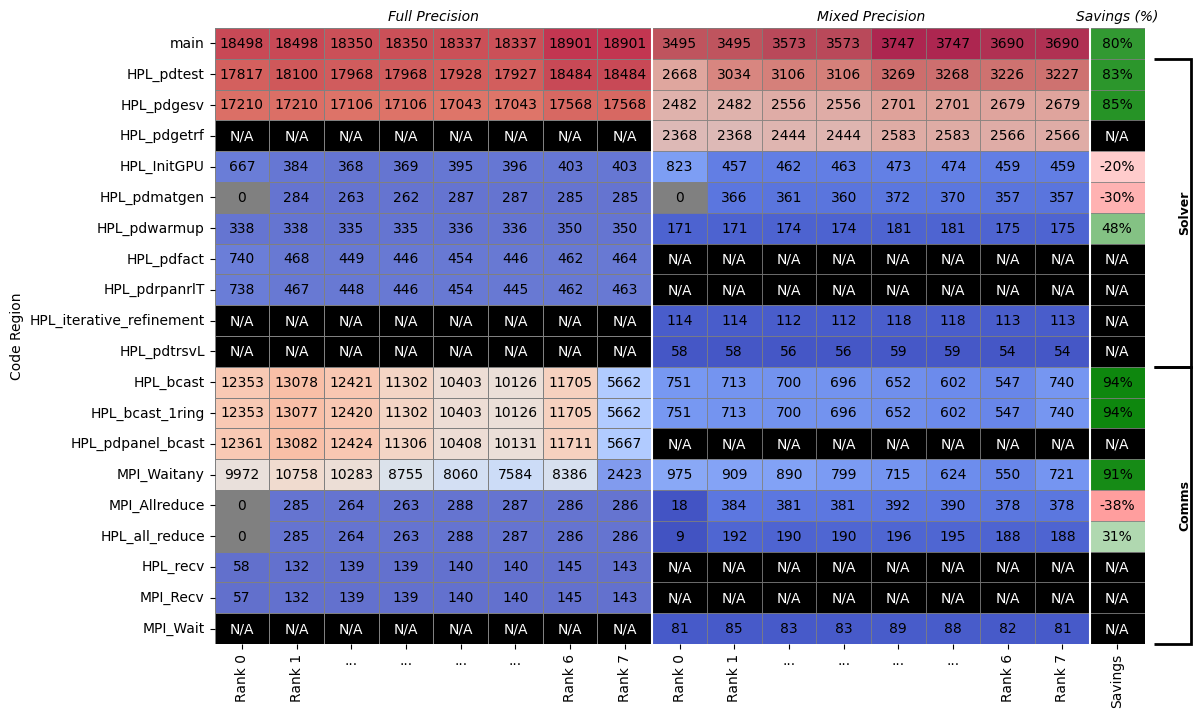

In [13]:
mi250x_rochpl_runs = mi250x_rochpl_runs.refresh()
mi250x_rochpl_mxp_runs = mi250x_rochpl_mxp_runs.refresh()
hpl_kwargs = dict(
    fp_prefix_replacements=[
        ('void HPL_', 'HPL_'),
    ],
    mxp_prefix_replacements=[
        ('HPLMXP_', 'HPL_'),
        ('int HPL_', 'HPL_'),
        ('void HPL_', 'HPL_'),
        ('HPL_p', 'HPL_pd'),
        ('HPL_Warmup', 'HPL_pdwarmup')
    ],
    region_category_map= {
        'HPL_all_reduce': 'Comms',
        'HPL_bcast_1ring': 'Comms',
        'HPL_bcast': 'Comms',
        'HPL_recv': 'Comms',
        'HPL_pdpanel_bcast': 'Comms',
        'HPL_reduce': 'Comms',
        'HPL_barrier': 'Comms',
        'MPI_Sendrecv': 'Comms',
        'MPI_Isend': 'Comms',
        'MPI_Irecv': 'Comms',
        'MPI_Wait': 'Comms',
        'MPI_Waitany': 'Comms',
        'MPI_Comm_split': 'Comms',
        'MPI_Waitall': 'Comms',
        'MPI_Barrier': 'Comms',
        'MPI_Bcast': 'Comms',
        'MPI_Reduce': 'Comms',
        'MPI_Allreduce': 'Comms',
        'MPI_Send': 'Comms',
        'MPI_Recv': 'Comms',
        'HPL_pdgesv': 'Solver',
        'HPL_pdtest': 'Solver',
        'HPL_InitGPU': 'Solver',
        'HPL_pdmatgen': 'Solver',
        'HPL_pdfact': 'Solver',
        'HPL_pdrpanrlT': 'Solver',
        'HPL_pdpanrlT': 'Solver',
        'HPL_pdtrsvL': 'Solver',
        'HPL_pdgetrf': 'Solver',
        'HPL_pdwarmup': 'Solver',
        'HPL_getrf': 'Solver',
        'HPL_pdtrsvU': 'Solver',
        'HPL_iterative_refinement': 'Solver',
    },
    max_count=20
)

visualize_code_region_energy_table(
    MI250X_HPL_RANKS_TO_METRICS,
    mi250x_rochpl_runs,
    mi250x_rochpl_mxp_runs,
    title='MI250X rocHPL Code Region Energy Attribution (Inclusive)',
    **hpl_kwargs
)

# visualize_code_region_energy_table(
#     MI250X_HPL_RANKS_TO_METRICS,
#     mi250x_rochpl_runs,
#     mi250x_rochpl_mxp_runs,
#     title='MI250X rocHPL Code Region Energy Attribution (Exclusive)',
#     exclusive=True,
#     **hpl_kwargs
# )


In [14]:
if 'mi250x_rochpl_runs' in globals():
    del mi250x_rochpl_runs
if 'mi250x_rochpl_mxp_runs' in globals():
    del mi250x_rochpl_mxp_runs

gc.collect()

33991

In [ ]:
if 'mi250x_hpg_runs' not in globals():
    mi250x_hpg_runs = Ensemble.from_trace_paths(
        MI250X_TRACES.get('HPG', []),
        MI250X_HPG_NODE_RANKS,
    )
if 'mi250x_hpg_mxp_runs' not in globals():
    mi250x_hpg_mxp_runs = Ensemble.from_trace_paths(
        MI250X_TRACES.get('HPG_MXP', []),
        MI250X_HPG_NODE_RANKS,
    )

Loading callgraphs:   0%|          | 0/3072 [00:00<?, ?it/s]           

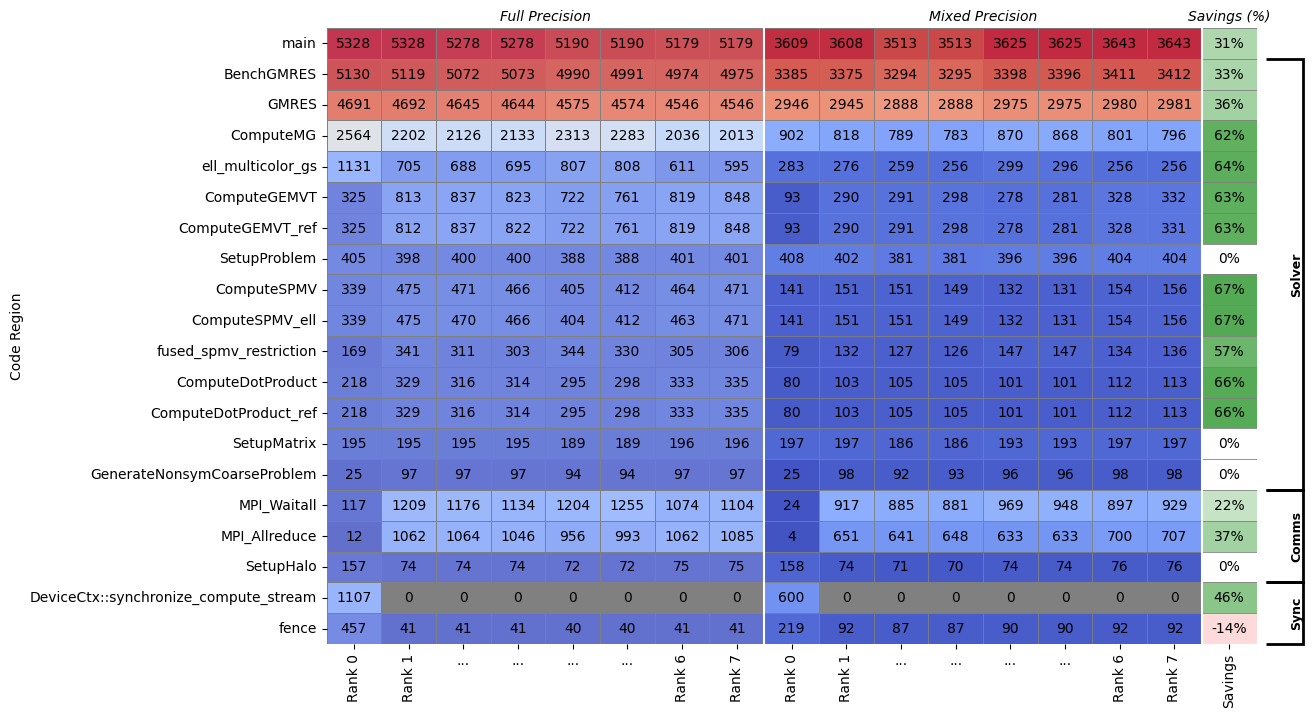

In [ ]:
hpg_kwargs = dict(
    fp_prefix_replacements=[
        ('int ', ''),
        ('void ', '')
    ],
    mxp_prefix_replacements=[
        ('int GMRES_IR', 'int GMRES'),
        ('int ', ''),
        ('void ', '')
    ],
    region_category_map= {
        'BenchGMRES': 'Solver',
        'GMRES': 'Solver',
        'ComputeMG': 'Solver',
        'ComputeGEMVT': 'Solver',
        'ComputeGEMVT_ref': 'Solver',
        'ell_multicolor_gs': 'Solver',
        'ell_multicolor_gs_zero_initial': 'Solver',
        'SetupProblem': 'Solver',
        'ComputeSPMV': 'Solver',
        'ComputeSPMV_ell': 'Solver',
        'fused_spmv_restriction': 'Solver',
        'ComputeDotProduct': 'Solver',
        'ComputeDotProduct_ref': 'Solver',
        'SetupMatrix': 'Solver',
        'DeviceCtx::synchronize_compute_stream': 'Sync',
        'DeviceCtx::pinned_host_free': 'Sync',
        'DeviceCtx::pinned_host_alloc': 'Sync',
        'fence': 'Sync',
        'DeviceCtx::DeviceCtx': 'Sync',
        'DeviceCtx::~DeviceCtx': 'Sync',
        'GenerateNonsymCoarseProblem': 'Solver',
        'GenerateNonsymProblem_v1_ref': 'Solver',
        'SetupHalo': 'Comms',
        'SetupHalo_ref': 'Comms',
        'GenerateNonsymProblem': 'Solver',
        'MPI_Comm_split': 'Comms',
        'MPI_Finalize': 'Comms',
        'MPI_Sendrecv': 'Comms',
        'MPI_Isend': 'Comms',
        'MPI_Irecv': 'Comms',
        'MPI_Wait': 'Comms',
        'MPI_Waitall': 'Comms',
        'MPI_Barrier': 'Comms',
        'MPI_Bcast': 'Comms',
        'MPI_Reduce': 'Comms',
        'MPI_Allreduce': 'Comms',
        'MPI_Send': 'Comms',
        'MPI_Recv': 'Comms',
    },
    max_count=20
)

visualize_code_region_energy_table(MI250X_HPG_RANKS_TO_METRICS, mi250x_hpg_runs, mi250x_hpg_mxp_runs, title='MI250X HPG-MxP Code Region Energy Attribution (Inclusive)',
    **hpg_kwargs
)

# visualize_code_region_energy_table(MI250X_HPG_RANKS_TO_METRICS, mi250x_hpg_runs, mi250x_hpg_mxp_runs, title='MI250X HPG Code Region Energy Attribution (Exclusive)', exclusive=True,
#     **hpg_kwargs
# )

In [ ]:
# visualize_code_region_energy_table(MI250X_HPG_RANKS_TO_METRICS, mi250x_hpg_runs, mi250x_hpg_mxp_runs, title='MI250X HPG Code Region Energy Attribution (Exclusive)', exclusive=True,
#     **hpg_kwargs,
#     filter_up_to_time=2.75,  # seconds
# )

if 'mi250x_hpg_runs' in globals():
    del mi250x_hpg_runs
if 'mi250x_hpg_mxp_runs' in globals():
    del mi250x_hpg_mxp_runs

gc.collect()

34100

# MI300A Results

In [ ]:
if 'mi300a_rochpl_runs' not in globals():
    mi300a_rochpl_runs = Ensemble.from_trace_paths(
        MI300A_TRACES.get('ROCHPL', []),
        MI300A_HPL_NODE_RANKS,
    )

if 'mi300a_rochpl_mxp_runs' not in globals():
    mi300a_rochpl_mxp_runs = Ensemble.from_trace_paths(
        MI300A_TRACES.get('ROCHPL_MXP', []),
        MI300A_HPL_NODE_RANKS,
    )

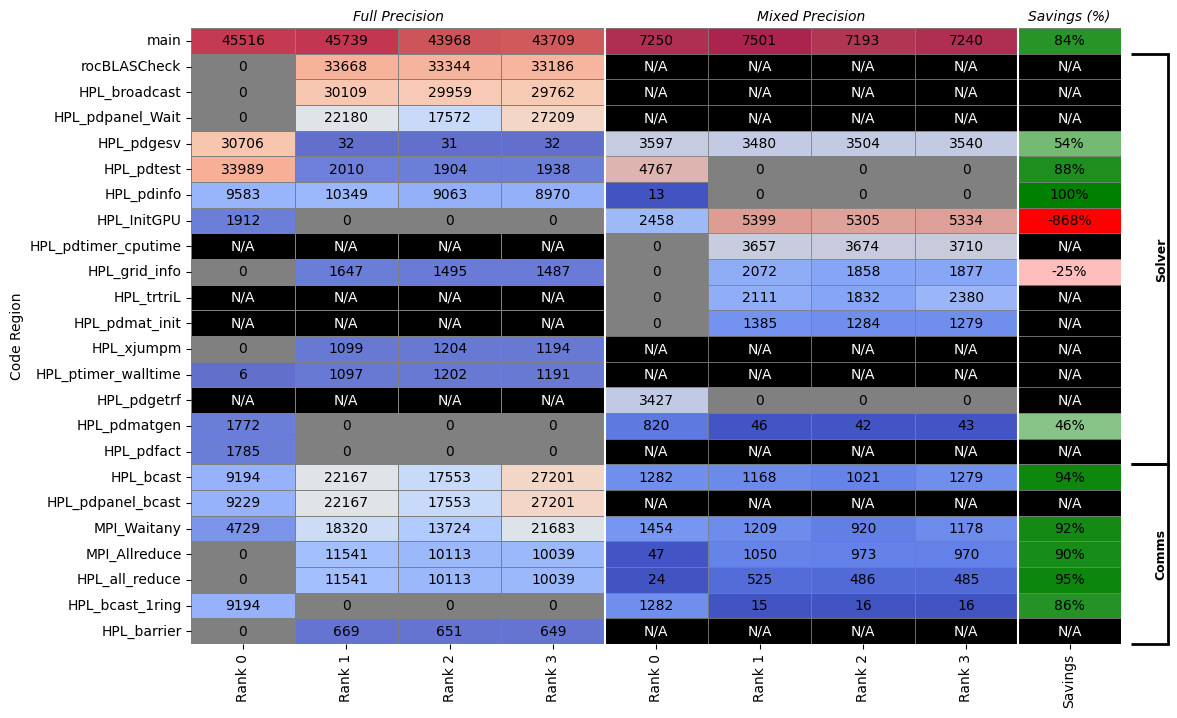

In [ ]:
mi300a_rochpl_runs = mi300a_rochpl_runs.refresh()
mi300a_rochpl_mxp_runs = mi300a_rochpl_mxp_runs.refresh()
hpl_kwargs = dict(
    fp_prefix_replacements=[
        ('void HPL_', 'HPL_'),
    ],
    mxp_prefix_replacements=[
        ('HPLMXP_', 'HPL_'),
        ('int HPL_', 'HPL_'),
        ('void HPL_', 'HPL_'),
        ('HPL_p', 'HPL_pd'),
        ('HPL_Warmup', 'HPL_pdwarmup')
    ],
    region_category_map= {
        'HPL_all_reduce': 'Comms',
        'HPL_bcast_1ring': 'Comms',
        'HPL_bcast': 'Comms',
        'HPL_recv': 'Comms',
        'HPL_pdpanel_bcast': 'Comms',
        'HPL_reduce': 'Comms',
        'HPL_barrier': 'Comms',
        'MPI_Sendrecv': 'Comms',
        'MPI_Isend': 'Comms',
        'MPI_Irecv': 'Comms',
        'MPI_Wait': 'Comms',
        'MPI_Waitany': 'Comms',
        'MPI_Comm_split': 'Comms',
        'MPI_Waitall': 'Comms',
        'MPI_Barrier': 'Comms',
        'MPI_Bcast': 'Comms',
        'MPI_Reduce': 'Comms',
        'MPI_Allreduce': 'Comms',
        'MPI_Send': 'Comms',
        'MPI_Recv': 'Comms',
        'HPL_pdgesv': 'Solver',
        'HPL_pdtest': 'Solver',
        'HPL_InitGPU': 'Solver',
        'HPL_pdmatgen': 'Solver',
        'HPL_pdfact': 'Solver',
        'HPL_pdrpanrlT': 'Solver',
        'HPL_pdpanel_Wait': 'Solver',
        'HPL_pdtimer_cputime': 'Solver',
        'HPL_pdpanrlT': 'Solver',
        'HPL_pdtrsvL': 'Solver',
        'HPL_pdgetrf': 'Solver',
        'HPL_pdwarmup': 'Solver',
        'HPL_getrf': 'Solver',
        'HPL_pdtrsvU': 'Solver',
        'HPL_iterative_refinement': 'Solver',
        'rocBLASCheck': 'Solver',
        'HPL_pdinfo': 'Solver',
        'HPL_grid_info': 'Solver',
        'HPL_trtriL': 'Solver',
        'HPL_pdmat_init': 'Solver',
        'HPL_xjumpm': 'Solver',
        'HPL_ptimer_walltime': 'Solver',
        'HPL_broadcast': 'Solver',
        'HPL_fprintf': 'Solver',
    },
    max_count=24,
    # filter_up_to_time=2.8,
    filter_functions=[
        # 'HPL_InitGPU(HPL_S_grid const*)',
        # 'HPLMXP_InitGPU(HPLMXP_S_grid const&)',
    ]
)

visualize_code_region_energy_table(
    MI300A_HPL_RANKS_TO_METRICS,
    mi300a_rochpl_runs,
    mi300a_rochpl_mxp_runs,
    title='MI300A rocHPL Code Region Energy Attribution (Inclusive)',
    **hpl_kwargs
)

# visualize_code_region_energy_table(
#     MI300A_HPL_RANKS_TO_METRICS,
#     mi300a_rochpl_runs,
#     mi300a_rochpl_mxp_runs,
#     title='MI300A rocHPL Code Region Energy Attribution (Exclusive)',
#     exclusive=True,
#     **hpl_kwargs
# )

In [ ]:
if 'mi300a_rochpl_runs' in globals():
    del mi300a_rochpl_runs
if 'mi300a_rochpl_mxp_runs' in globals():
    del mi300a_rochpl_mxp_runs

gc.collect()

23579

In [ ]:
if 'mi300a_hpg_runs' not in globals():
    mi300a_hpg_runs = Ensemble.from_trace_paths(
        MI300A_TRACES.get('HPG', []),
        MI300A_HPG_NODE_RANKS,
    )
print("Loaded MI300A HPG runs")
if 'mi300a_hpg_mxp_runs' not in globals():
    mi300a_hpg_mxp_runs = Ensemble.from_trace_paths(
        MI300A_TRACES.get('HPG_MXP', []),
        MI300A_HPG_NODE_RANKS,
    )
print("Loaded MI300A HPG MXP runs")

Loaded MI300A HPG runs


Loaded MI300A HPG MXP runs


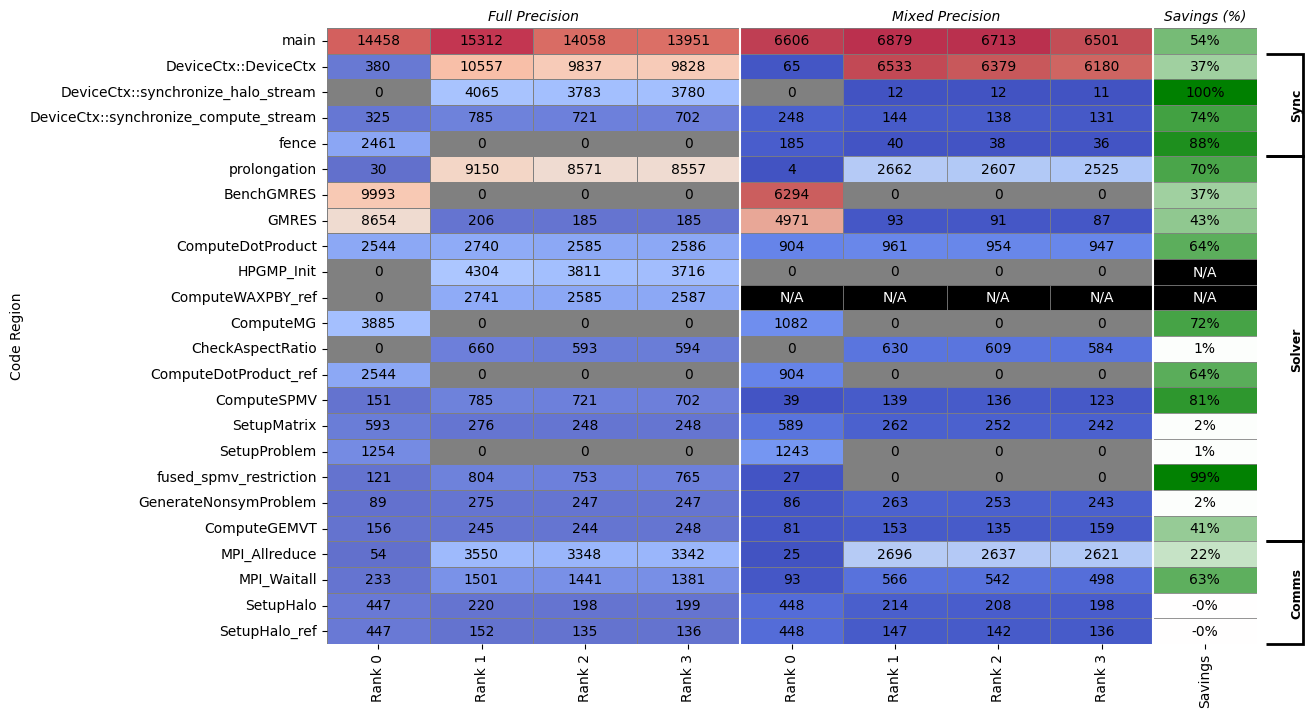

In [ ]:
hpg_kwargs = dict(
    fp_prefix_replacements=[
        ('int ', ''),
        ('void ', '')
    ],
    mxp_prefix_replacements=[
        ('int GMRES_IR', 'int GMRES'),
        ('int ', ''),
        ('void ', '')
    ],
    region_category_map= {
        'BenchGMRES': 'Solver',
        'GMRES': 'Solver',
        'ComputeMG': 'Solver',
        'ComputeGEMVT': 'Solver',
        'ComputeGEMVT_ref': 'Solver',
        'ell_multicolor_gs': 'Solver',
        'ell_multicolor_gs_zero_initial': 'Solver',
        'SetupProblem': 'Solver',
        'ComputeSPMV': 'Solver',
        'ComputeSPMV_ell': 'Solver',
        'fused_spmv_restriction': 'Solver',
        'ComputeDotProduct': 'Solver',
        'ComputeDotProduct_ref': 'Solver',
        'SetupMatrix': 'Solver',
        'DeviceCtx::synchronize_halo_stream': 'Sync',
        'DeviceCtx::synchronize_compute_stream': 'Sync',
        'DeviceCtx::pinned_host_free': 'Sync',
        'DeviceCtx::pinned_host_alloc': 'Sync',
        'fence': 'Sync',
        'DeviceCtx::DeviceCtx': 'Sync',
        'DeviceCtx::~DeviceCtx': 'Sync',
        'GenerateNonsymCoarseProblem': 'Solver',
        'CheckAspectRatio': 'Solver',
        'ComputeWAXPBY_ref': 'Solver',
        'GenerateNonsymProblem_v1_ref': 'Solver',
        'SetupHalo': 'Comms',
        'SetupHalo_ref': 'Comms',
        'GenerateNonsymProblem': 'Solver',
        'MPI_Comm_split': 'Comms',
        'MPI_Finalize': 'Comms',
        'MPI_Sendrecv': 'Comms',
        'MPI_Isend': 'Comms',
        'MPI_Irecv': 'Comms',
        'MPI_Wait': 'Comms',
        'MPI_Waitall': 'Comms',
        'MPI_Barrier': 'Comms',
        'MPI_Bcast': 'Comms',
        'MPI_Reduce': 'Comms',
        'MPI_Allreduce': 'Comms',
        'MPI_Send': 'Comms',
        'MPI_Recv': 'Comms',
        'HPGMP_Init': 'Solver',
        'prolongation': 'Solver',
        'mytimer': 'Sync'
    },
    filter_functions=[
        'std::vector<long long, std::allocator<long long> >::_M_default_append(unsigned long)',
        'std::vector<int, std::allocator<int> >::_M_default_append(unsigned long)',
        'void CopyVector<double, double>(Vector<double> const&, Vector<double>&)',
        'void CopyVector<double, float>(Vector<double> const&, Vector<float>&)',
        'void CopyVector<float, double>(Vector<float> const&, Vector<double>&)',
        
        'MultiVector<float>::MultiVector(int, int, int, DeviceCtx*)',
        'MultiVector<float>::initialize(int, int, int, DeviceCtx*)',
        'MultiVector<float>::get_multi_vector(int, int)',
        'MultiVector<float>::get_vector(int)',
        'MultiVector<float>::~MultiVector()',

        'MultiVector<double>::MultiVector(int, int, int, DeviceCtx*)',
        'MultiVector<double>::initialize(int, int, int, DeviceCtx*)',
        'MultiVector<double>::get_multi_vector(int, int)',
        'MultiVector<double>::get_vector(int)',
        'MultiVector<double>::~MultiVector()',
    ],
    max_count=24
)


visualize_code_region_energy_table(MI300A_HPG_RANKS_TO_METRICS, mi300a_hpg_runs, mi300a_hpg_mxp_runs, title='MI300A HPG-MxP Code Region Energy Attribution (Inclusive)',
    **hpg_kwargs
)

# visualize_code_region_energy_table(MI300A_HPG_RANKS_TO_METRICS, mi300a_hpg_runs, mi300a_hpg_mxp_runs, title='MI300A HPG Code Region Energy Attribution (Exclusive)', exclusive=True,
#     **hpg_kwargs
# )

In [ ]:
if 'mi300a_hpg_runs' in globals():
    del mi300a_hpg_runs
if 'mi300a_hpg_mxp_runs' in globals():
    del mi300a_hpg_mxp_runs
gc.collect()

23688

In [ ]:
# Get the end time of the notebook
NOTEBOOK_END_TIME = time.time()
print(f"Notebook end time: {NOTEBOOK_END_TIME}")
print(f"Notebook end at {NOTEBOOK_END_TIME} ({datetime.datetime.fromtimestamp(NOTEBOOK_END_TIME)})")

NOTEBOOK_DURATION = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
print(f"Notebook execution time: {NOTEBOOK_DURATION:.2f} seconds")

Notebook end time: 1764880447.5102437
Notebook end at 1764880447.5102437 (2025-12-04 15:34:07.510244)
Notebook execution time: 3165.49 seconds
